In [10]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [62]:
ds = xr.open_dataset('igrf11.nc')
ds.data

<xarray.DataArray 'data' (level: 11, lon: 361, lat: 181)> Size: 6MB
[718751 values with dtype=float64]
Coordinates:
  * level    (level) float64 88B 0.0 300.0 600.0 900.0 ... 2.4e+03 2.7e+03 3e+03
  * lon      (lon) float64 3kB 0.0 1.0 2.0 3.0 4.0 ... 357.0 358.0 359.0 360.0
  * lat      (lat) float64 1kB -90.0 -89.0 -88.0 -87.0 ... 87.0 88.0 89.0 90.0

In [28]:
def plot_netcdf_heatmap(
    file_path: str,
    var_name: str,
    lon_range: tuple[float, float],
    lat_range: tuple[float, float],
    cmap: str = "viridis",
    output_file: str = "heatmap.png",
)->None:
    ds = xr.open_dataset(file_path)
    data = ds[var_name].isel(level=0)

    # Отрисовка
    fig = plt.figure(figsize=(10, 6))
    '''
        ccrs.PlateCarree(): задает систему координат и проекцию Plate Carrée 
        (равнопромежуточная цилиндрическая проекция). В ней долгота и широта 
        представлены в виде обычных градусов от -180 до 180 и от -90 до 90, 
        образуя прямую прямоугольную сетку.
        '''
    ax = plt.axes(projection=ccrs.PlateCarree())

    min_lon, max_lon = lon_range
    min_lat, max_lat = lat_range
    # Граница отображения
    ax.set_extent([min_lon, max_lon, min_lat, max_lat], crs=ccrs.PlateCarree())


    #Псевдоцветной график с неправильной прямоугольной сеткой.
    '''
        ax: указывает axes, в которых должен быть нарисован график

        transform: указывает cartopy систему координат, в которой хранятся координаты входных данных (
        широта и долгота). Функция PlateCarree() означает, что в данных используются стандартные 
        градусы широты/долготы (как в проекции осей, созданной ранее). Это позволяет cartopy 
        корректно проецировать данные из своей собственной системы координат на картографическую 
        проекцию оси (даже если они были разными).

        cmap=cmap: устанавливает цветовую карту, используемую для сопоставления значений данных с 
        цветами.

        add_colorbar=True: При этом автоматически создается цветовая шкала для графика, иллюстрирующая 
        взаимосвязь между цветами и значениями данных.
    '''
    data.plot.pcolormesh(
        ax=ax,
        x='lon',
        y='lat',
        transform=ccrs.PlateCarree(),
        cmap=cmap,
    )

    ax.coastlines() #Рисуем береговые линии
    ax.add_feature(cfeature.BORDERS, linestyle= ":") # Наносим государственные границы с пунктирной линией
    gl =ax.gridlines(draw_labels=True) #Создаем координатную сетку параллелей и меридианов
    gl.top_labels = False
    gl.right_labels = False 

    plt.title(f"{var_name} | level = 0")
    plt.savefig(output_file, dpi=300, bbox_inches="tight")
    plt.show()

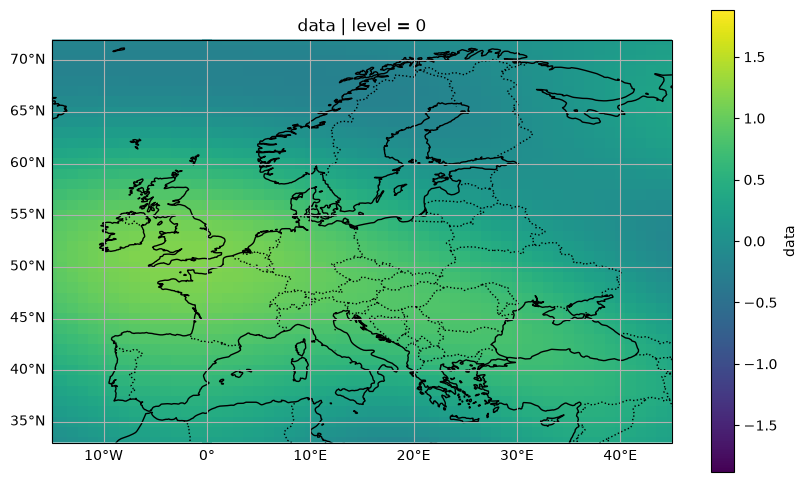

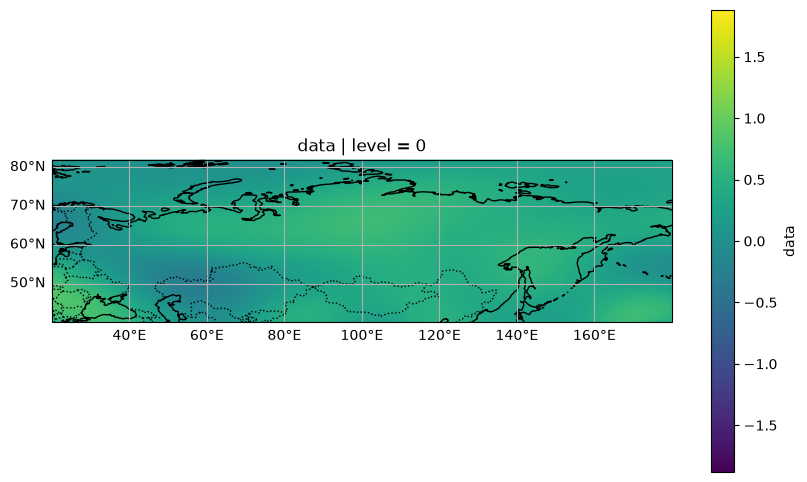

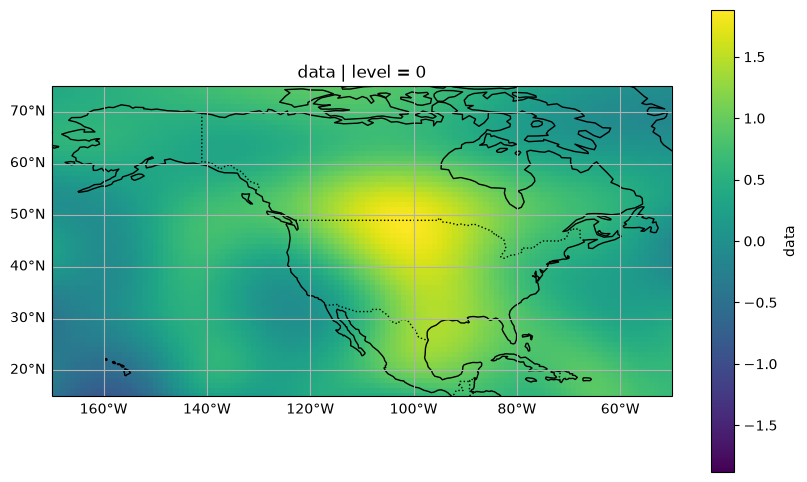

In [29]:
from matplotlib.cm import viridis


plot_netcdf_heatmap(
        file_path="s362d.nc",
        var_name="data",
        lon_range=(-15.0, 45.0),
        lat_range=(33.0, 72.0),
        cmap='viridis',
        output_file ='europe.png'
    )
plot_netcdf_heatmap(
        file_path="s362d.nc",
        var_name="data",
        lon_range=(20.0, 180.0),
        lat_range=(40.0, 82.0),
        cmap='viridis',
        output_file ='russia.png'
    )
plot_netcdf_heatmap(
        file_path="s362d.nc",
        var_name="data",
        lon_range=(-170.0, -50.0),
        lat_range=(15.0, 75.0),
        cmap='viridis',
        output_file ='north_america.png'
    )
None